## Workflow

### Overview
1. Data Loading
    - DataLoader objects for efficient batch processing
    - Dataset transformations and preprocessing

2. Model Architecture
    - Dropout layers for regularization
    - Batch normalization for stable training
    - L1/L2 regularization

3. Training Pipeline
    - Training loop implementation
    - Batch iteration 
    - Loss calculation with regularization
    - Optimization steps

4. Evaluation
    - Model validation
    - Metrics calculation
    - Performance monitoring

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
# Set random seed for reproducibility
torch.manual_seed(42)

In [3]:
df = pd.read_csv("data/fmnist_small.csv")

In [4]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


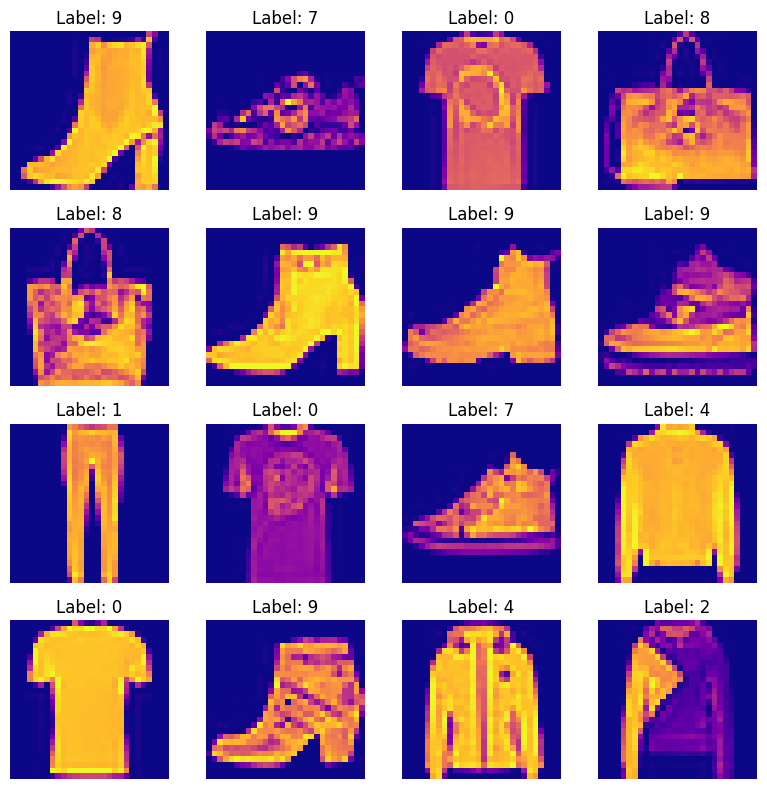

In [5]:
# Create 4x4 grid of images
def plot_images(images, labels):
    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    for i, ax in enumerate(axes.flat):
        ax.imshow(images[i].reshape(28, 28), cmap='plasma')
        ax.set_title(f"Label: {labels[i]}")
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# Plot the first 16 images
plot_images(df.iloc[:16, 1:].values, df.iloc[:16, 0].values)

In [6]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:, 1:].values, df.iloc[:, 0].values, test_size=0.2, random_state=42)

# Scaling the features
X_train = X_train / 255.0
X_test = X_test / 255.0

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
X_test_tensor = torch.FloatTensor(X_test)
y_train_tensor = torch.LongTensor(y_train)
y_test_tensor = torch.LongTensor(y_test)

In [7]:
print(f"X_train shape: {X_train_tensor.shape}")
print(f"y_train shape: {y_train_tensor.shape}")

X_train shape: torch.Size([4800, 784])
y_train shape: torch.Size([4800])


In [8]:
# Create a custom dataset
class CustomDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.FloatTensor(features)
        self.labels = torch.LongTensor(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

In [9]:
# Create DataLoader for training and testing
train_dataset = CustomDataset(X_train_tensor, y_train_tensor)
test_dataset = CustomDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [10]:
# Define the neural network model
class MNISTModel(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(num_features, 128),
            # Apply BatchNorm1d
            nn.BatchNorm1d(128),
            nn.ReLU(),
            # Apply dropout, after activation
            nn.Dropout(0.5),
            nn.Linear(128, 64),
            # Apply BatchNorm1d
            nn.BatchNorm1d(64),
            nn.ReLU(),
            # Apply dropout
            nn.Dropout(0.5),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.model(x)

In [11]:
# Initialize the model, loss function, and optimizer
num_features = X_train.shape[1]
model = MNISTModel(num_features)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, weight_decay=0.0001)

In [12]:
# set learning rate and number of epochs
learning_rate = 0.01
num_epochs = 100

In [13]:
# Training loop
train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%")

    # Validation loop
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    test_loss = running_loss / len(test_loader)
    test_accuracy = 100 * correct / total
    test_losses.append(test_loss)
    test_accuracies.append(test_accuracy)
    print(f"Epoch [{epoch+1}/{num_epochs}], Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%")
    print("-" * 50)

Epoch [1/100], Train Loss: 1.7234, Train Accuracy: 43.35%
Epoch [1/100], Test Loss: 1.2586, Test Accuracy: 70.67%
--------------------------------------------------
Epoch [2/100], Train Loss: 1.2712, Train Accuracy: 61.44%
Epoch [2/100], Test Loss: 0.9666, Test Accuracy: 75.58%
--------------------------------------------------
Epoch [3/100], Train Loss: 1.0966, Train Accuracy: 66.27%
Epoch [3/100], Test Loss: 0.8221, Test Accuracy: 76.25%
--------------------------------------------------
Epoch [4/100], Train Loss: 0.9968, Train Accuracy: 69.08%
Epoch [4/100], Test Loss: 0.7441, Test Accuracy: 77.75%
--------------------------------------------------
Epoch [5/100], Train Loss: 0.9204, Train Accuracy: 70.73%
Epoch [5/100], Test Loss: 0.6888, Test Accuracy: 78.42%
--------------------------------------------------
Epoch [6/100], Train Loss: 0.8566, Train Accuracy: 72.08%
Epoch [6/100], Test Loss: 0.6421, Test Accuracy: 79.92%
--------------------------------------------------
Epoch [7/1

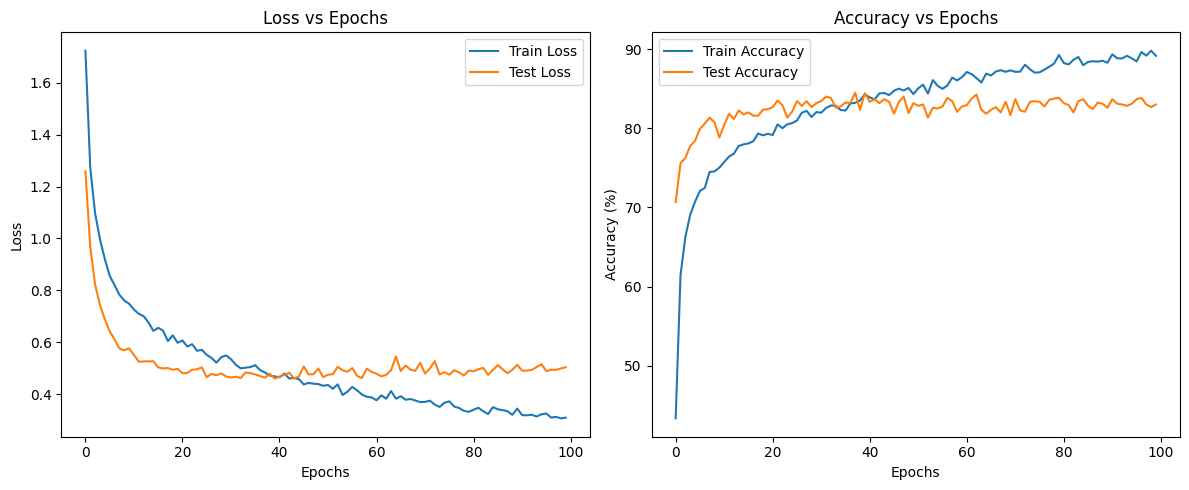

In [14]:
# Plot training and testing loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.title('Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(test_accuracies, label='Test Accuracy')
plt.title('Accuracy vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.tight_layout()
plt.show()